In [224]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
from scipy.io import loadmat
from scipy.optimize import curve_fit
import os

%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

## Load dataset

In [197]:
dat = loadmat('data_final/dataset_Mar23_2026.mat')

locals().update(dat) #Populates all variables: ek, chi, rac, mc, omc

ek = ek.flatten()
chi = chi.flatten()

dat2 = loadmat('data_final/chi0.35_data_Mar17_2026.mat') # Dataset for chi=0.35, computed till Ek=1e-9

ek_chi35  = dat2['ek'].flatten()
rac_chi35 = dat2['rac'].flatten()
mc_chi35  = dat2['mc'].flatten()
omc_chi35 = dat2['omc'].flatten()

ek2d, chi2d = np.meshgrid(ek,chi,indexing='ij') # 2d grid of ek and chi to make matrix multiplications easier

os.makedirs('figures', exist_ok=True)

def slice_data(chiUser=0.50):
    idx = np.argmin(np.abs(chi - chiUser))
    raSlice = rac[:,idx]
    mSlice = mc[:,idx]
    omSlice = omc[:,idx]

    return raSlice, mSlice, omSlice

In [198]:
# Defining some generic useful stuff for plotting

major_ticks = np.arange(0.,1.1,0.2)
minor_ticks = np.arange(0.05,0.96,0.03)

sizeAndFonts = 'notebook'
plotStyle = 'light'

if sizeAndFonts == 'notebook':
    tksz = 15
    axfontsize=20
    lgfontsize=13
    figW = 5.5
    figH = 4.5
    figsize = (figW,figH)
    figsizeSubplots = (13.5,4.5)
    figsizeE = (8,4.5)
    markerSize1 = 5
    markerSize2 = 10
elif sizeAndFonts == 'paper':
    tksz = 40
    axfontsize=50
    lgfontsize=30
    figW = 11
    figH = 9
    figsize = (figW,figH)
    figsizeSubplots = (27,9)
    figsizeE = (16,9)
    markerSize1 = 10
    markerSize2 = 20

gridAlpha = 0.3

if plotStyle == 'dark':
    plt.style.use("dark_background")
    plt.rcParams.update({
        "axes.facecolor"   : "#1b1b1b",
        "figure.facecolor" : "#1b1b1b",
        "figure.edgecolor" : "#1b1b1b",
        "savefig.facecolor": "#1b1b1b",
        "savefig.edgecolor": "#1b1b1b"})

def set_ax_params(ax,grid=False):
    ax.set_xticks(minor_ticks, minor=True)
    ax.set_xticks(major_ticks)
    ax.set_xlabel(r'$\chi = r_i/r_o$',fontsize=axfontsize)

    if grid:
       ax.grid(True,which='minor', alpha=gridAlpha,axis='both',color='gray',ls='-')
       for x in [0.2,0.5,0.8]:
           ax.axvline(x=x,alpha=gridAlpha,color='gray',lw=0.5,zorder=-3)
    else:
        ax.grid(False)

    ax.tick_params(which='major',labelsize=tksz,length=10,direction='out')
    ax.tick_params(which='minor',length=5)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

def plot_crit(chi,ek,datPlot,ax=None,ls=None,cmap=None,ilabel=False):

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    if cmap is None:
        cmap = cm.plasma_r

    colors = cmap(np.linspace(0.2,0.8,len(ek)))

    for k, ekk in enumerate(ek):
        expIdx = int(np.log10(ekk))
        mant = int(ekk/10**(expIdx-1))

        if ilabel:
            if mant == 10:
                label = r'$10^{%d}$' %expIdx
            else:
                label = r'$%d\times 10^{%d}$' %(mant,expIdx)
        else:
            label = None

        if ls is None:
            ax.semilogy(chi, datPlot[k,:], 'o',color=colors[k],label=label)
        else:
            ax.semilogy(chi, datPlot[k,:], ls=ls,color=colors[k],label=label)

    set_ax_params(ax,grid=True)

    return ax

def plot_crit_E(chi,ek,dat,fig=None,ax=None,scatter=True,line_collection=False,ls='--'):

    colors_E = cm.rainbow(np.linspace(0.2,0.8,len(chi)))
    
    if ax is None:
        fig, ax = plt.subplots(figsize=figsizeE)

    if len(chi) == 31:
        line_collection = True

    if scatter:
        for k, kchi in enumerate(chi):
            ax.scatter(ek,dat[:,k],marker='o',color=colors_E[k])
    else:
        for k, kchi in enumerate(chi):
            ax.semilogy(ek,dat[:,k],ls=ls,color=colors_E[k],label=r'$\chi = %.2f$' %kchi)

    if line_collection:
        from matplotlib.collections import LineCollection
        lines = [np.column_stack([ek,dat[:,k]]) for k in range(len(chi))]
        line_collection = LineCollection(lines,array=chi,cmap='rainbow',linestyles=ls)
        ax.add_collection(line_collection)
        fig.colorbar(line_collection, label=r"$\chi$")

    ax.set_xlabel(r'$E$',fontsize=axfontsize)

    ax.grid(True,which='both', alpha=0.3,axis='both',color='gray',ls='-')
    ax.xaxis.grid(True, which='minor')
    ax.set_xscale('log')
    ax.tick_params(which='major',axis='both',labelsize=tksz,direction='out',length=10)
    ax.tick_params(which='minor',axis='both',direction='out',length=5)

    return fig,ax

# Comparison with Dormy et al., 2004

For $\chi = 0.35$, we use values directly from Dormy et al., 2004. For the rest, we obtain the values by a least squares fit for $E \leq 10^{-5}$

### $f_{Ra} Ra_c (f_E E)^{4/3} = (R_c + (f_E E)^{2/9} R_1 + (f_E E)^{1/6}\tilde{R})$

The factors $f_{Ra}$ and $f_E$ are to take care of different definitions of Rayleigh and Ekman number between ours and that of Dormy et al., 2004:

$$f_{Ra}=\displaystyle\frac{(1-\chi)^4}{\chi},  f_E = \displaystyle\frac{2}{(1-\chi)^2}$$

In [199]:
# Creating classes so we can pass the chi value to curve_fit

class DormyFit:

    def __init__(self):
        pass


    def get_fit(self,ek_chi,Rc,R1,R_tilde):

        facRa = (1-self.chi)**4/self.chi
        facEk = 0.5 * (1-self.chi)**2

        ek_dormy = ek_chi * facEk

        Rac_dormy = (Rc + ek_dormy**(2./9.) * R1 + ek_dormy**(1./6.) * R_tilde) * facEk**(-4./3.)
        Rac_dormy *= facRa

        return Rac_dormy

    def get_fit_zero(self,ek_chi,Rc,R1): #Without R_tilde

        facRa = (1-self.chi)**4/self.chi
        facEk = 0.5 * (1-self.chi)**2

        ek_dormy = ek_chi * facEk

        Rac_dormy = (Rc + ek_dormy**(2./9.) * R1) * facEk**(-4./3.)
        Rac_dormy *= facRa

        return Rac_dormy


class SimpleFit:

    def __init__(self):
        pass

    def get_fit(self,ek,Rc,R1,R_tilde):
        return (Rc + ek**(2./9.) * R1 + ek**(1./6.) * R_tilde)

    def get_fit_zero(self,ek,Rc,R1): #Without R_tilde
        return (Rc + ek**(2./9.) * R1)

lw = 2 # Define linewidth for plots

### Test fits for $\chi = 0.35$

chi = 0.35
----------
Dormy et al., 2004: Rc, R1, R_tilde = 0.286, 4.161, 0.279

Least Squares Fit: Rc, R1, R_tilde = 0.286, (4.853, 1.75e-07

Least Squares Fit assuming Niiler-Bissophh: Rc, R1, R_tilde = 0.407, 23.656, -9.62e+00



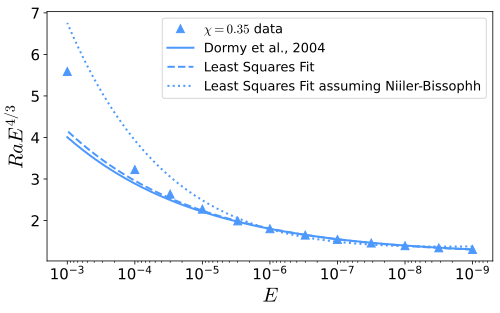

In [226]:
####################
#   chi = 0.35     #
####################

Rc = 0.285933
R1 = 4.16053
R_tilde = 0.27902

print("chi = 0.35")
print("----------")
print("Dormy et al., 2004: Rc, R1, R_tilde = %.3f, %.3f, %.3f\n" %(Rc, R1, R_tilde))

chiComp = 0.35

facRa = (1-chiComp)**4/chiComp
facEk = 0.5 * (1-chiComp)**2

ek_plot = 10**( np.linspace(-9,-3,500))
ek_dormy = ek_plot * facEk

Rac_dormy = (Rc + ek_dormy**(2./9.) * R1 + ek_dormy**(1./6.) * R_tilde) * facEk**(-4./3.)

Rac_dormy *= facRa

fig, ax = plt.subplots(figsize=figsizeE)

ax.semilogx(Ek_chi35,rac_chi35 * Ek_chi35**(4./3.),'^',color='#4c98fc',ms=0.8*markerSize2,label=r'$\chi = 0.35$ data')
ax.semilogx(ek_plot,Rac_dormy,ls='-',color='#4c98fc',lw=lw,label=r'Dormy et al., 2004')


Fit = DormyFit()
Fit.chi = 0.35
facEk = 0.5 * (1-Fit.chi)**2

mask = Ek_chi35 < 1e-5

[Rc,R1,R_tilde], pcov = curve_fit(Fit.get_fit,Ek_chi35[mask],rac_chi35[mask] * Ek_chi35[mask]**(4./3.), p0=[0.5, 0.5, 0.5],bounds=([0,0,0],[np.inf,np.inf,np.inf]))

print("Least Squares Fit: Rc, R1, R_tilde = %.3f, (%.3f, %.2e\n" %(Rc, R1, R_tilde))

Rac_dormy = Fit.get_fit(ek_plot,Rc,R1,R_tilde)
ax.semilogx(ek_plot,Rac_dormy,ls='--',color='#4c98fc',lw=lw,label="Least Squares Fit")

# [Rc,R1], pcov = curve_fit(Fit.get_fit_zero,Ek_chi35[mask],rac_chi35[mask] * Ek_chi35[mask]**(4./3.), p0=[0.5, 0.5],bounds=([0,0],[np.inf,np.inf]))

# print("Least Squares Fit assuming zero R_tilde: Rc, R1, R_tilde = (%.3f), (%.3f), 0.0\n" %(Rc, R1))

# Rac_dormy = Fit.get_fit_zero(ek_plot,Rc,R1)
# # ax.semilogx(ek_plot,Rac_dormy,ls=':',color='#4c98fc',lw=lw,label=r"Least Squares Fit assuming $\tilde{R}=0$")
# ax.semilogx(ek_plot,Rac_dormy,ls='-.',color='purple',lw=lw,label=r"Least Squares Fit assuming $\tilde{R}=0$")

[Rc,R1,R_tilde], pcov = curve_fit(Fit.get_fit,Ek_chi35[mask],rac_chi35[mask] * Ek_chi35[mask]**(4./3.), p0=[0.5, 0.5, -9.625],bounds=([0,0,-9.63],[np.inf,np.inf,-9.62]))


print("Least Squares Fit assuming Niiler-Bissophh: Rc, R1, R_tilde = %.3f, %.3f, %.2e\n" %(Rc, R1, R_tilde))

Rac_dormy = Fit.get_fit(ek_plot,Rc,R1,R_tilde)
ax.semilogx(ek_plot,Rac_dormy,ls=':',color='#4c98fc',lw=lw,label="Least Squares Fit assuming Niiler-Bissophh")
ax.set_xlabel(r'$E$',fontsize=axfontsize)
ax.set_ylabel(r'$Ra E^{4/3}$',fontsize=axfontsize)
ax.tick_params(labelsize=tksz)
ax.invert_xaxis()
ax.legend(fontsize=lgfontsize)
plt.savefig('figures/dormy_comparison.pdf',bbox_inches='tight')

## Fits for all $\chi$

In [201]:
Rc      = np.zeros_like(chi)
R1      = np.zeros_like(chi)
R_tilde = np.zeros_like(chi)

ekMask = ek < 1e-4 #Fit only for Ekman numbers <= 1e-5

for k, chiComp in enumerate(chi):
    fit = SimpleFit()
    ek_curve_fit = ek[ekMask]
    R_curve_fit = rac[ekMask,k] * ek[ekMask]**(4./3.)
    [Rc[k],R1[k],R_tilde[k]], pcov = curve_fit(fit.get_fit,ek_curve_fit,R_curve_fit,
                                               p0=[0.2, 0.2, 0.2],
                                               bounds=([-np.inf, -np.inf, -np.inf],[np.inf,np.inf,np.inf]))
    # [Rc[k],R1[k]], pcov = curve_fit(fit.get_fit_zero,ek[ekMask],rac[ekMask,k] * ek[ekMask]**(4./3.), p0=[0.2, 0.2],bounds=([0, 0],[np.inf,np.inf]))

### Plot critical parameters

Rc, R1, R_tilde at chi=0.35: 1.347, 28.662, -8.768
Fit parameters:
\log_{10}\Rc = (-19.411) \chi^5 + (51.017) \chi^4 + (-52.574) \chi^3 + (26.051) \chi^2 + (-6.171) \chi + (0.688)
\log_{10}\Rone = (-45.645) \chi^5 + (121.000) \chi^4 + (-126.068) \chi^3 + (64.563) \chi^2 + (-17.324) \chi + (3.441)
\log_{10}|\Rtilde| = (-74.623) \chi^5 + (197.265) \chi^4 + (-203.905) \chi^3 + (103.125) \chi^2 + (-26.813) \chi + (3.869)


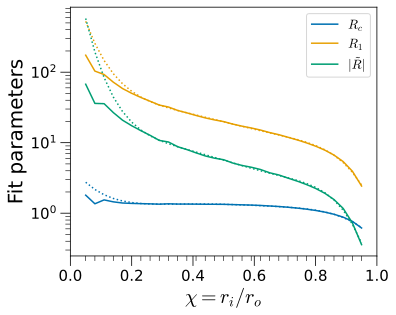

In [202]:
chiMask = chi > 0.2

colors = ["#0072B2", "#E69F00", "#009E73"]  # Wong (2011) colorblind-safe palette

fig, ax = plt.subplots(figsize=figsize)
ax.semilogy(chi, np.abs(Rc), label=r"$R_c$", color=colors[0])
ax.semilogy(chi, np.abs(R1), label=r"$R_1$", color=colors[1])
ax.semilogy(chi, np.abs(R_tilde), label=r"$|\tilde{R}|$", color=colors[2])

print("Rc, R1, R_tilde at chi=0.35: %.3f, %.3f, %.3f" %(Rc[10], R1[10], R_tilde[10]))
# print("Rc, R1, R_tilde at chi=0.35: %.3f, %.3f" %(Rc[10], R1[10]))



pc = np.polyfit(chi[chiMask],np.log10(Rc[chiMask]),deg=5)
p1 = np.polyfit(chi[chiMask],np.log10(R1[chiMask]),deg=5)
p_tilde = np.polyfit(chi[chiMask],np.log10(np.abs(R_tilde[chiMask])),deg=5)

Rc_Fit = 10**np.polyval(pc,chi)
R1_Fit = 10**np.polyval(p1,chi)
R_tilde_Fit = -10**np.polyval(p_tilde,chi)

ax.semilogy(chi,Rc_Fit,ls=':', color=colors[0])
ax.semilogy(chi,R1_Fit,ls=':', color=colors[1])
ax.semilogy(chi,np.abs(R_tilde_Fit),ls=':', color=colors[2])

print("Fit parameters:")
print("\\log_{10}\\Rc = (%.3f) \\chi^5 + (%.3f) \\chi^4 + (%.3f) \\chi^3 + (%.3f) \\chi^2 + (%.3f) \\chi + (%.3f)" % tuple(pc))
print("\\log_{10}\\Rone = (%.3f) \\chi^5 + (%.3f) \\chi^4 + (%.3f) \\chi^3 + (%.3f) \\chi^2 + (%.3f) \\chi + (%.3f)" % tuple(p1))
print("\\log_{10}|\\Rtilde| = (%.3f) \\chi^5 + (%.3f) \\chi^4 + (%.3f) \\chi^3 + (%.3f) \\chi^2 + (%.3f) \\chi + (%.3f)" % tuple(p_tilde))

set_ax_params(ax)
ax.set_ylabel("Fit parameters",fontsize=axfontsize)
ax.legend(fontsize=lgfontsize)
plt.savefig('figures/FitParameters.pdf',bbox_inches='tight')

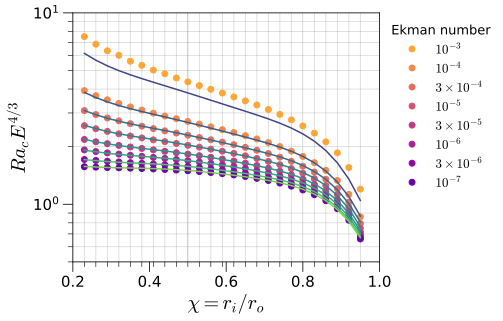

In [208]:
fig, ax = plt.subplots(figsize=figsize)

chiMask = chi > 0.2

Fit = SimpleFit()
Fit.chi = chi2d
Rc2d = 10**np.polyval(pc,chi2d)
R12d = 10**np.polyval(p1,chi2d)
R_tilde2d = -10**np.polyval(p_tilde,chi2d)
Rac_Fit_chi = Fit.get_fit(ek2d,Rc2d,R12d,R_tilde2d)

ax = plot_crit(chi[chiMask],ek,rac[:,chiMask]*ek2d[:,chiMask]**(4/3),
               ax=ax,ilabel=True)

ax = plot_crit(chi[chiMask],ek,Rac_Fit_chi[:,chiMask],ax=ax,
               ls='-',cmap=cm.viridis)

ax.set_ylabel(r'$Ra_c E^{4/3}$',fontsize=axfontsize)

ax.legend(fontsize=lgfontsize,bbox_to_anchor=(1, 1),
          title="Ekman number",title_fontsize=lgfontsize,
          frameon=False)
ax.set_ylim(0.5,10)
ax.set_xlim(0.2,1)
# plt.show()
plt.savefig('figures/chi_RacEk43_fit.pdf',bbox_inches='tight')


## Plot with respect to Ekman

In [210]:
# Recompute Rac_Fit to low Ekman numbers

ek_fit = 10**(np.linspace(-15,-3,500))[::-1]
ek_fit2d, chi_fit2d = np.meshgrid(ek_fit,chi,indexing='ij')

Fit = SimpleFit()
Rc2d = 10**np.polyval(pc,chi_fit2d)
R12d = 10**np.polyval(p1,chi_fit2d)
R_tilde2d = -10**np.polyval(p_tilde,chi_fit2d)
Rac_Fit = Fit.get_fit(ek_fit2d,Rc2d,R12d,R_tilde2d)

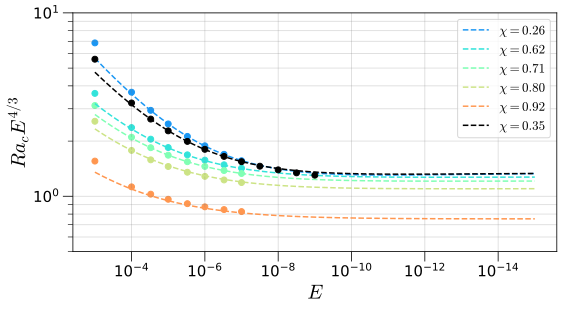

In [212]:
# Plotting

fig,ax = plt.subplots(figsize=figsizeE)

chiList = [0.26,0.62,0.71,0.8,0.92]

chiMask = np.full(len(chi),False)

for chiSelect in chiList:
    chiMask = chiMask | (chi == chiSelect)

plot_crit_E(chi[chiMask],ek,rac[:,chiMask]*ek2d[:,chiMask]**(4/3),fig=fig,ax=ax,scatter=True)
plot_crit_E(chi[chiMask],ek_fit,Rac_Fit[:,chiMask],fig=fig,ax=ax,scatter=False,ls='--')

ax.plot(ek_chi35,rac_chi35*ek_chi35**(4/3),'ko')
ax.plot(ek_fit,Rac_Fit[:,chi == 0.35],'k--',label=r'$\chi=0.35$')

ax.set_ylabel(r"$Ra_c E^{4/3}$", fontsize=axfontsize)
ax.invert_xaxis()
ax.set_ylim(0.5,10)

ax.legend(fontsize=lgfontsize)
fig.tight_layout()
plt.savefig('figures/RacE43_v_E.pdf',bbox_inches='tight')

In [223]:
# Rac_sat = np.mean(Rac_Fit[ek_fit < 1e-14,:] * ek_fit2d[ek_fit < 1e-14,:]**(-4/3),axis=0)
# fig, ax = plt.subplots(figsize=figsize)
# ax.plot(chi[chi>0.2],Rac_sat[chi > 0.2]/1e19)
# set_ax_params(ax)
# ax.set_ylabel(r'$Ra_c (\times 10^{19})$',fontsize=axfontsize)